# Лабораторная работа 5. Детекция цифр в городских номерах.

In [1]:
from pathlib import Path
import tarfile
import shutil
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from sklearn.model_selection import train_test_split
import torch

ROOT = Path.cwd().resolve()
if ROOT.name != "lab5":
    ROOT = ROOT / "lab5"
DATA = ROOT / "data"
YOLO_ROOT = ROOT / "svhn_yolo"
STREET_PHOTOS = ROOT / "street_photos"

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: mps


## 1. Исходный датасет SVHN

In [2]:
def ensure_svhn_split(split):
    split_dir = DATA / split
    annotation_file = split_dir / "digitStruct.mat"
    if not annotation_file.exists():
        archive = DATA / f"{split}.tar.gz"
        if not archive.exists():
            raise FileNotFoundError(
                f"Missing {archive}. Download it from ufldl.stanford.edu/housenumbers"
            )
        with tarfile.open(archive, "r:gz") as tar:
            tar.extractall(DATA, filter="data")
    return split_dir

for split in ("train", "test"):
    split_dir = ensure_svhn_split(split)
    print(f"{split}: {len(list(split_dir.glob('*.png')))} images")

train: 33402 images
test: 13068 images


## 2. Чтение разметки

In [3]:
def _read_str(hf, ref):
    return "".join(chr(c[0]) for c in hf[ref][:])

def _read_attr(hf, attr):
    if len(attr) == 1:
        return [float(attr[0][0])]
    return [float(hf[attr[i][0]][0][0]) for i in range(len(attr))]

def parse_digitstruct(mat_path):
    rows = []
    with h5py.File(mat_path, "r") as hf:
        names = hf["/digitStruct/name"]
        bboxes = hf["/digitStruct/bbox"]
        for i in range(len(names)):
            name = _read_str(hf, names[i][0])
            bbox_group = hf[bboxes[i][0]]
            labels = _read_attr(hf, bbox_group["label"])
            lefts = _read_attr(hf, bbox_group["left"])
            tops = _read_attr(hf, bbox_group["top"])
            widths = _read_attr(hf, bbox_group["width"])
            heights = _read_attr(hf, bbox_group["height"])
            for lab, l, t, w, h in zip(labels, lefts, tops, widths, heights):
                rows.append({"image": name, "label": int(lab) % 10, "x": l, "y": t, "w": w, "h": h})
    return pd.DataFrame(rows)

train_boxes = parse_digitstruct(DATA / "train" / "digitStruct.mat")
test_boxes = parse_digitstruct(DATA / "test" / "digitStruct.mat")

print("train:", len(train_boxes), "boxes in", train_boxes['image'].nunique(), "images")
print("test: ", len(test_boxes),  "boxes in", test_boxes['image'].nunique(),  "images")

train: 73257 boxes in 33402 images
test:  26032 boxes in 13068 images


In [4]:
train_boxes.head()

,image,label,x,y,w,h
0,1.png,1,246.0,77.0,81.0,219.0
1,1.png,9,323.0,81.0,96.0,219.0
2,2.png,2,77.0,29.0,23.0,32.0
3,2.png,3,98.0,25.0,26.0,32.0
4,3.png,2,17.0,5.0,8.0,15.0


## 3. Проверка разметки

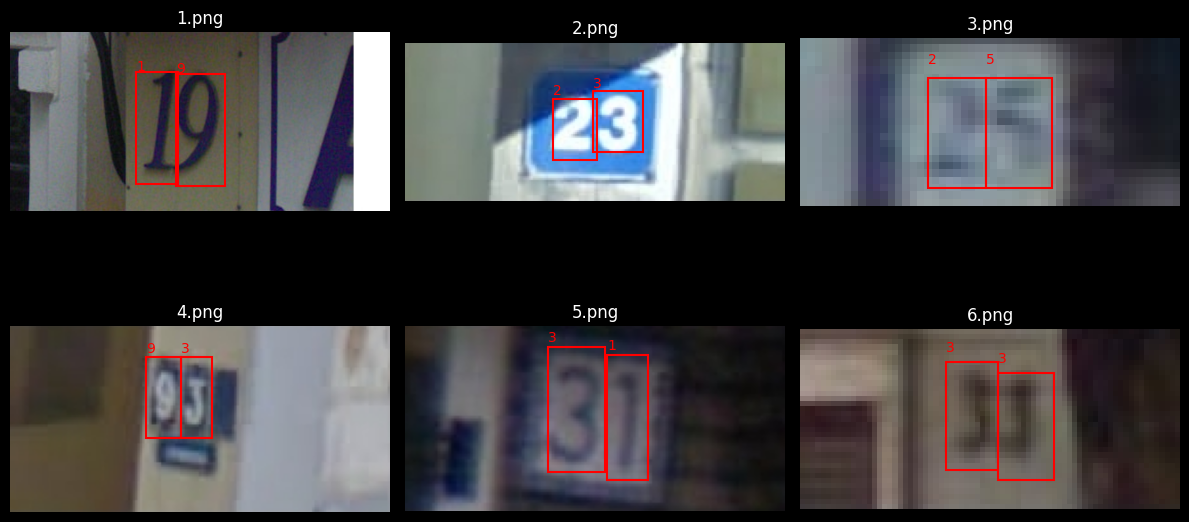

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, img_name in zip(axes.flat, train_boxes["image"].drop_duplicates().head(6)):
    img = Image.open(DATA / "train" / img_name)
    ax.imshow(img)
    for _, b in train_boxes[train_boxes["image"] == img_name].iterrows():
        rect = patches.Rectangle((b["x"], b["y"]), b["w"], b["h"], linewidth=1.5, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(b["x"], b["y"] - 2, str(b["label"]), color="red", fontsize=10)
    ax.axis("off")
    ax.set_title(img_name)
plt.tight_layout(); plt.show()

## 4. Подготовка данных для YOLO

In [6]:
def write_yolo_split(boxes_df, src_dir, dst_root, split_name, image_names):
    img_dir = dst_root / "images" / split_name
    lab_dir = dst_root / "labels" / split_name
    img_dir.mkdir(parents=True, exist_ok=True)
    lab_dir.mkdir(parents=True, exist_ok=True)
    name_to_boxes = {n: g for n, g in boxes_df.groupby("image")}
    for img_name in image_names:
        src = src_dir / img_name
        if not src.exists():
            continue
        img = Image.open(src)
        W, H = img.size
        dst_img = img_dir / img_name
        if not dst_img.exists():
            shutil.copy(src, dst_img)
        lines = []
        for _, b in name_to_boxes[img_name].iterrows():
            raw_x, raw_y = float(b["x"]), float(b["y"])
            x1 = max(0.0, raw_x)
            y1 = max(0.0, raw_y)
            x2 = min(float(W), raw_x + float(b["w"]))
            y2 = min(float(H), raw_y + float(b["h"]))
            if x2 <= x1 or y2 <= y1:
                continue
            cx = ((x1 + x2) / 2) / W
            cy = ((y1 + y2) / 2) / H
            bw = (x2 - x1) / W
            bh = (y2 - y1) / H
            class_id = int(b["label"])
            lines.append(f"{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
        (lab_dir / img_name.replace(".png", ".txt")).write_text("\n".join(lines))

train_imgs = train_boxes["image"].drop_duplicates().sample(4000, random_state=42).tolist()
test_imgs = test_boxes["image"].drop_duplicates().tolist()
tr_imgs, val_imgs = train_test_split(train_imgs, test_size=1000, random_state=42)

print("train:", len(tr_imgs), "val:", len(val_imgs), "test:", len(test_imgs))

write_yolo_split(train_boxes, DATA / "train", YOLO_ROOT, "train", tr_imgs)
write_yolo_split(train_boxes, DATA / "train", YOLO_ROOT, "val", val_imgs)
write_yolo_split(test_boxes,  DATA / "test",  YOLO_ROOT, "test", test_imgs)

for split, names in {"train": tr_imgs, "val": val_imgs, "test": test_imgs}.items():
    paths = [str((YOLO_ROOT / "images" / split / name).resolve()) for name in names]
    (YOLO_ROOT / f"{split}.txt").write_text("\n".join(paths))
print("YOLO dataset is ready")

train: 3000 val: 1000 test: 13068
YOLO dataset is ready


In [7]:
yaml_text = f"""path: {YOLO_ROOT}
train: train.txt
val: val.txt
test: test.txt
nc: 10
names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
"""
yaml_path = ROOT / "svhn.yaml"
yaml_path.write_text(yaml_text)
print(yaml_text)

path: /Users/ruslan/dev/itmo-cv-labs/lab5/svhn_yolo
train: train.txt
val: val.txt
test: test.txt
nc: 10
names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']



## 5. Fine-tuning готовой YOLOv8n

In [8]:
from ultralytics import YOLO
print("Ultralytics is ready")

Ultralytics is ready


In [9]:
run_name = "svhn_digits_continue"
run_dir = ROOT / "runs" / run_name
best_weights = run_dir / "weights" / "best.pt"

if best_weights.exists():
    print("Trained weights found; skipping training")
else:
    model = YOLO("yolov8n.pt")
    model.train(
        data=str(yaml_path),
        epochs=8,
        imgsz=320,
        batch=16,
        device=device,
        workers=0,
        project=str(ROOT / "runs"),
        name=run_name,
        exist_ok=True,
        seed=42,
    )
    print("Training complete")

model = YOLO(str(best_weights))

Trained weights found; skipping training


### Динамика обучения YOLOv8n на SVHN

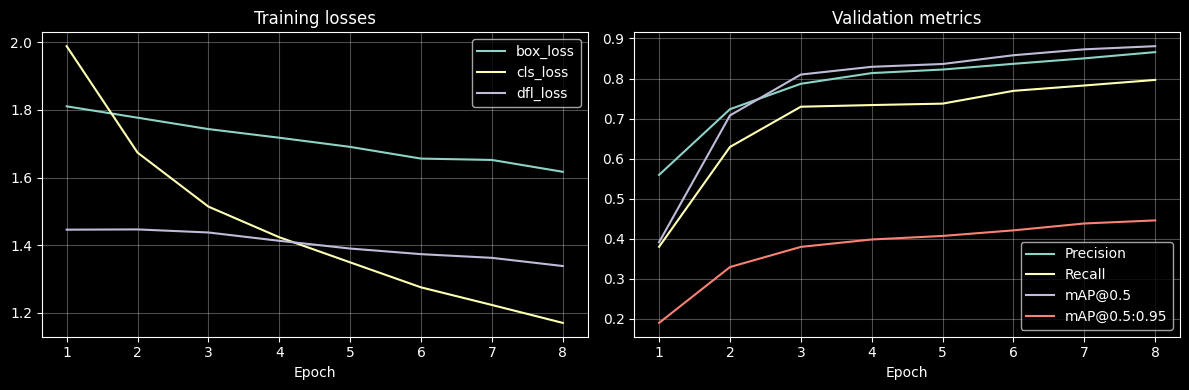

In [10]:
history_path = run_dir / "results.csv"
history = pd.read_csv(history_path)
history.columns = history.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for column in ("train/box_loss", "train/cls_loss", "train/dfl_loss"):
    axes[0].plot(history["epoch"], history[column], label=column.removeprefix("train/"))
axes[0].set_title("Training losses")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

metric_columns = {
    "metrics/precision(B)": "Precision",
    "metrics/recall(B)": "Recall",
    "metrics/mAP50(B)": "mAP@0.5",
    "metrics/mAP50-95(B)": "mAP@0.5:0.95",
}
for column, label in metric_columns.items():
    axes[1].plot(history["epoch"], history[column], label=label)
axes[1].set_title("Validation metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 6. Метрики на официальном test SVHN

In [11]:
model = YOLO(str(best_weights))
metrics = model.val(
    data=str(yaml_path), split="test", imgsz=320, batch=16, device=device,
    project=str(ROOT / "runs"), name="test_metrics", exist_ok=True, verbose=False,
)
print(f"mAP@0.5     = {metrics.box.map50:.4f}")
print(f"mAP@0.5:.95 = {metrics.box.map:.4f}")
print(f"Precision   = {metrics.box.mp:.4f}")
print(f"Recall      = {metrics.box.mr:.4f}")

Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.11.0 MPS (Apple M1 Pro)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 168.7±137.6 MB/s, size: 38.4 KB)
val: Scanning /Users/ruslan/dev/itmo-cv-labs/lab5/svhn_yolo/labels/test.cache... 13068 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13068/13068 1.4Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 817/817 2.6it/s 5:14<0.5s
                   all      13068      26032      0.816      0.691      0.775      0.352
Speed: 0.1ms preprocess, 1.7ms inference, 0.0ms loss, 5.8ms postprocess per image
Results saved to /Users/ruslan/dev/itmo-cv-labs/lab5/runs/test_metrics
mAP@0.5     = 0.7749
mAP@0.5:.95 = 0.3523
Precision   = 0.8162
Recall      = 0.6914


## 7. Примеры предсказаний на test

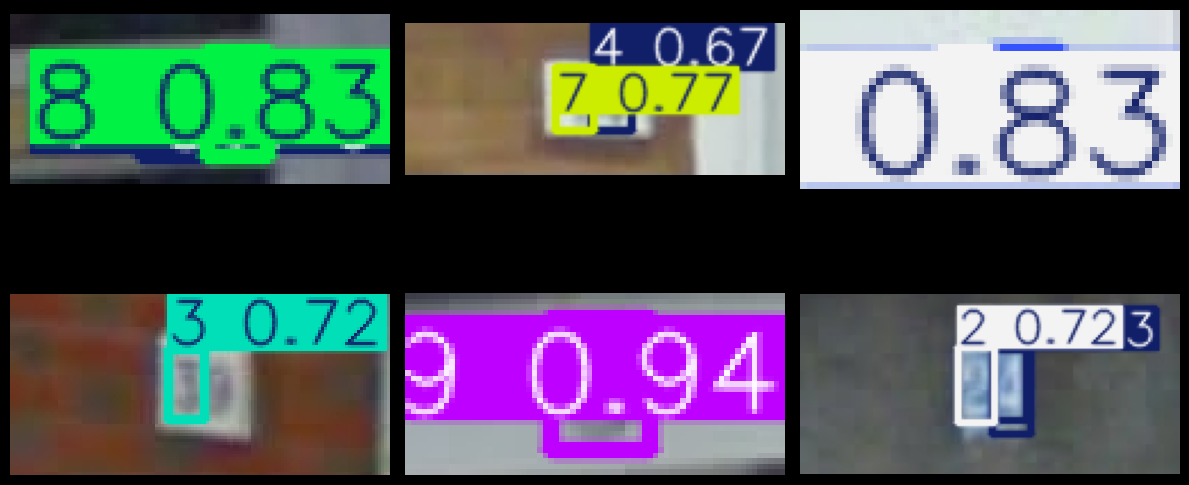

In [12]:
test_img_dir = YOLO_ROOT / "images" / "test"
sample_images = sorted(test_img_dir.glob("*.png"))[:6]
preds = model.predict(sample_images, imgsz=320, device=device, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, image_path, prediction in zip(axes.flat, sample_images, preds):
    ax.imshow(prediction.plot()[..., ::-1])
    ax.set_title(image_path.name)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 8. Собственные фотографии с улицы

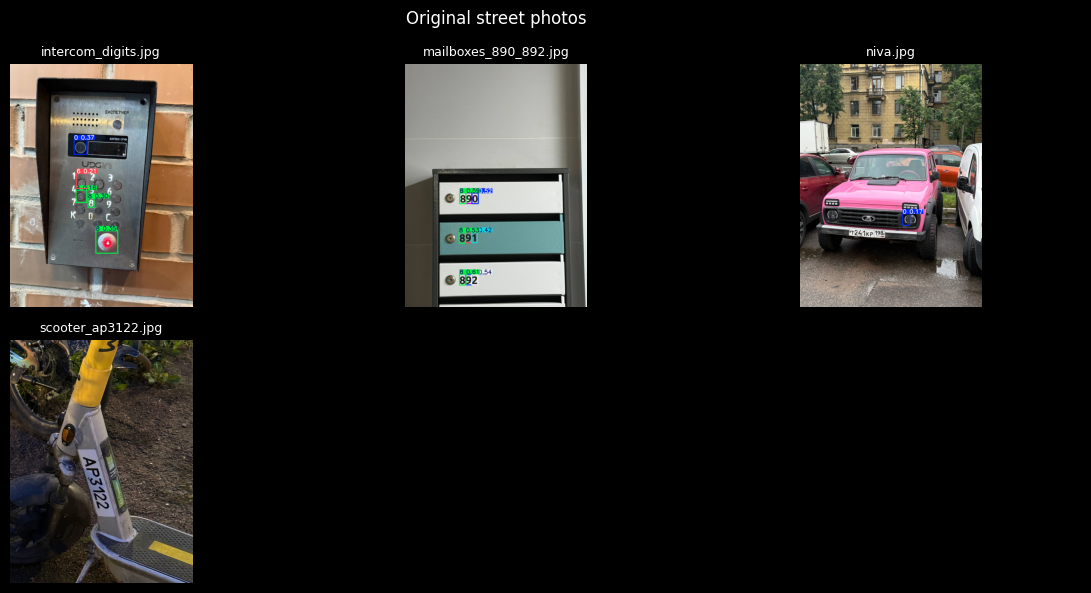

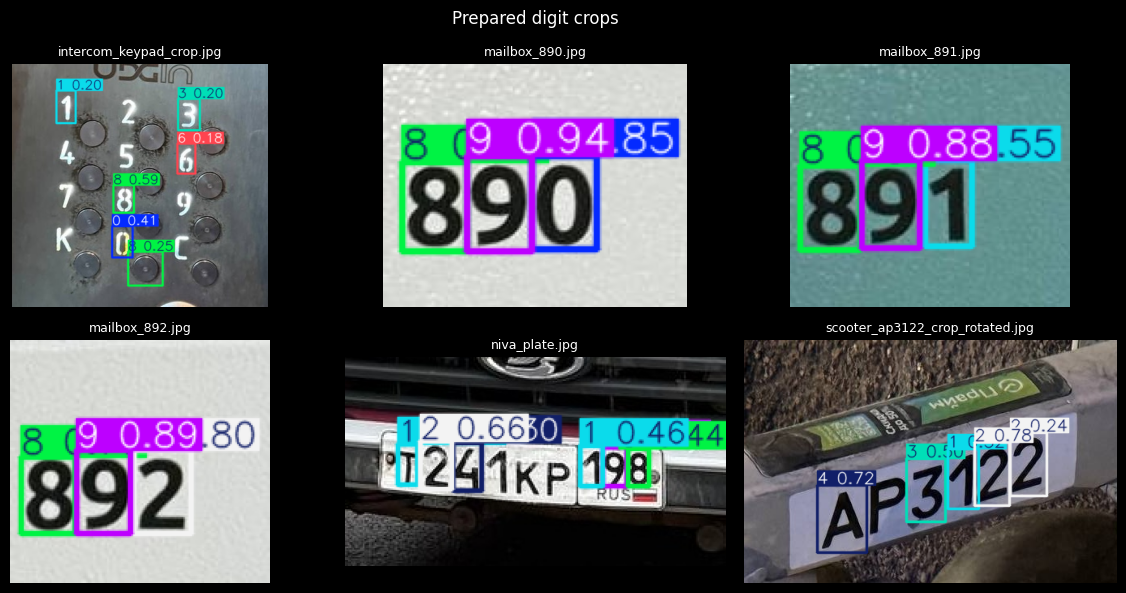

In [13]:
# Prepare crops from the original street photos
STREET_PHOTOS.mkdir(exist_ok=True)
prepared_dir = ROOT / "street_photos_prepared"
prepared_dir.mkdir(exist_ok=True)
prepared_imgs = []
mailboxes_path = STREET_PHOTOS / "mailboxes_890_892.jpg"
if mailboxes_path.exists():
    mailboxes = Image.open(mailboxes_path).convert("RGB")
    mailbox_crops = {
        "mailbox_890.jpg": (280, 640, 430, 760),
        "mailbox_891.jpg": (280, 840, 430, 970),
        "mailbox_892.jpg": (280, 1050, 430, 1190),
    }
    for name, box in mailbox_crops.items():
        output_path = prepared_dir / name
        mailboxes.crop(box).save(output_path, quality=95)
        prepared_imgs.append(output_path)

intercom_path = STREET_PHOTOS / "intercom_digits.jpg"
if intercom_path.exists():
    intercom = Image.open(intercom_path).convert("RGB")
    output_path = prepared_dir / "intercom_keypad_crop.jpg"
    intercom.crop((250, 520, 650, 900)).save(output_path, quality=95)
    prepared_imgs.append(output_path)

niva_path = STREET_PHOTOS / "niva.jpg"
if niva_path.exists():
    niva = Image.open(niva_path).convert("RGB")
    output_path = prepared_dir / "niva_plate.jpg"
    niva.crop((235, 815, 490, 955)).save(output_path, quality=95)
    prepared_imgs.append(output_path)

scooter_path = STREET_PHOTOS / "scooter_ap3122.jpg"
if scooter_path.exists():
    scooter = Image.open(scooter_path).convert("RGB")
    scooter_crop = scooter.crop((340, 520, 640, 980)).rotate(90, expand=True, fillcolor=(255, 255, 255))
    output_path = prepared_dir / "scooter_ap3122_crop_rotated.jpg"
    scooter_crop.save(output_path, quality=95)
    prepared_imgs.append(output_path)

# Run inference and visualize detections
def show_predictions(paths, imgsz, title):
    predictions = model.predict(paths, imgsz=imgsz, conf=0.15, iou=0.3, device=device, verbose=False)
    cols = 3
    rows = (len(predictions) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
    axes = np.atleast_1d(axes).flatten()
    for ax, source_path, prediction in zip(axes, paths, predictions):
        ax.imshow(prediction.plot()[..., ::-1])
        ax.axis("off")
        ax.set_title(source_path.name, fontsize=9)
    for ax in axes[len(predictions):]:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout(); plt.show()
    return predictions

raw_imgs = sorted(p for p in STREET_PHOTOS.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
prepared_imgs = sorted(prepared_imgs)
if not raw_imgs:
    print(f"Add photos to {STREET_PHOTOS} and rerun this cell")
else:
    raw_preds = show_predictions(raw_imgs, imgsz=640, title="Original street photos")
    if prepared_imgs:
        prepared_preds = show_predictions(prepared_imgs, imgsz=320, title="Prepared digit crops")